## Deep Learning Melody Generation using LSTM Neural Networks

**Objective:** To build and train a Long Short-Term Memory (LSTM) sequence model capable of learning the temporal patterns of audio signals. The model extracts Mel-Frequency Cepstral Coefficients (MFCCs) from a dataset of major and minor audio tracks, learns their progression, and generates novel, listenable audio sequences by predicting future MFCC frames.

**Techniques Used:**
* **Audio Signal Processing:** `librosa` for MFCC extraction and Mel-to-Audio inversion.
* **Deep Learning:** Multi-layer LSTM architecture with Dropout for sequence modeling using `TensorFlow/Keras`.
* **Autoregressive Generation:** Predicting future time steps based on a sliding window of past predictions, augmented with Gaussian noise for natural variance.

### Importing libraries

In [5]:
import os
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import IPython.display as ipd
from tensorflow.keras.callbacks import EarlyStopping
import librosa.display
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

### Dataset

In [11]:
# Set paths (Relative path for GitHub)
DATA_PATH = 'Audio_Files/' 
major_folder = os.path.join(DATA_PATH, 'Major')
minor_folder = os.path.join(DATA_PATH, 'Minor')

# Hyperparameters
n_mfcc = 20  
sequence_length = 30  
batch_size = 32
epochs = 50

### Feature Extraction

In [12]:
def load_and_extract_features(folder_path):
    features = []
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.wav'):
            file_path = os.path.join(folder_path, file_name)
            y, sr = librosa.load(file_path)
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
            features.append(mfccs.T)
    return features

### Sequence Creation

In [13]:
# Load and prepare dataset
major_features = load_and_extract_features(major_folder)
minor_features = load_and_extract_features(minor_folder)

# Prepare sequences
def create_sequences(features, seq_length):
    X, y = [], []
    for mfcc in features:
        for i in range(len(mfcc) - seq_length):
            X.append(mfcc[i:i + seq_length])
            y.append(mfcc[i + seq_length])
    return np.array(X), np.array(y)

In [14]:
X_major, y_major = create_sequences(major_features, sequence_length)
X_minor, y_minor = create_sequences(minor_features, sequence_length)

# Combine and label data (1 for major, 0 for minor)
X = np.concatenate((X_major, X_minor), axis=0)
y = np.concatenate((y_major, y_minor), axis=0)

In [15]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model

In [16]:
model = Sequential([
    LSTM(64, input_shape=(sequence_length, n_mfcc), return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(n_mfcc)  # Output layer with the same dimension as MFCC input
])

C:\Users\shrut\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(optimizer='adam', loss='mse')
model.summary()

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          21,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             660 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 57,524 (224.70 KB)

 Trainable params: 57,524 (224.70 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 4216.7090 - val_loss: 463.3524
Epoch 2/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 401.6132 - val_loss: 176.0463
Epoch 3/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 234.3749 - val_loss: 152.7767
Epoch 4/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 208.7375 - val_loss: 129.7563
Epoch 5/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 183.0804 - val_loss: 111.7306
Epoch 6/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 165.0543 - val_loss: 103.3005
Epoch 7/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 157.9809 - val_loss: 101.4860
Epoch 8/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 154.8092 - val_loss: 98.4442
Epoch 9/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - loss: 150.5002 - val_loss: 96.2174
Epoch 10/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 145.0255 - val_loss: 94.2867
Epoch 11/50
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - lo

In [18]:
# Evaluate
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE): {test_loss}")

# Save model 
model.save("melody_generator_model.h5")

359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 25.6937


Test Loss (MSE): 25.654239654541016


In [19]:
# Training loss (MSE) on the training data
train_loss = model.evaluate(X_train, y_train)
print(f"Training Loss (MSE): {train_loss}")

# Calculate test loss (MSE) on the test data
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE): {test_loss}")

1434/1434 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 23.8997
Training Loss (MSE): 24.203369140625
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 25.6937
Test Loss (MSE): 25.654239654541016


In [20]:
# Predict on train and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate R-squared score for training and test sets
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training R^2 Score: {train_r2}")
print(f"Test R^2 Score: {test_r2}")

1434/1434 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Training R^2 Score: 0.8740836977958679
Test R^2 Score: 0.8719713091850281


In [21]:
# Function to generate a sequence
def generate_sequence(model, start_sequence, sequence_length):
    generated_sequence = start_sequence.copy()#creating a copy to avoid making edition on original data
    
    for _ in range(sequence_length):
        prediction = model.predict(generated_sequence[-30:].reshape(1, -1, 20))  # selects last 30 time steps , 
        #The reshaping is required to match the expected input shape for the model
        generated_sequence = np.vstack([generated_sequence, prediction])
        
    return generated_sequence

In [22]:
def mfcc_to_audio(mfcc_sequence, sr=22050):
    S = librosa.feature.inverse.mfcc_to_mel(mfcc_sequence.T, n_mels=128)
    audio = librosa.feature.inverse.mel_to_audio(S, sr=sr)
    return audio

## Major

In [30]:
# Load a seed audio file and extract initial MFCCs
y, sr = librosa.load(os.path.join(major_folder, "Major_8.wav"))  # replace with actual file path
initial_mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T[:sequence_length]  # First sequence

# Generating  melody
generated_mfccs = generate_sequence(model, initial_mfccs, sequence_length=30)  # Generate 100 frames

# Convert generated MFCCs to audio
generated_audio = mfcc_to_audio(generated_mfccs, sr=sr)

# Play generated audio
ipd.Audio(generated_audio, rate=sr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━

## Minor

In [31]:
import IPython.display as ipd

# Load a seed audio file and extract initial MFCCs
y, sr = librosa.load(os.path.join(minor_folder, "Minor_8.wav"))  # replace with actual file path
initial_mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T[:sequence_length]  # First sequence

# Generate a melody
generated_mfccs = generate_sequence(model, initial_mfccs, sequence_length=30)  # Generate 100 frames

# Convert generated MFCCs to audio
generated_audio = mfcc_to_audio(generated_mfccs, sr=sr)

# Play generated audio
ipd.Audio(generated_audio, rate=sr)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

In [25]:
# Function to generate a sequence with added Gaussian noise
def generate_sequence_with_noise(model, start_sequence, sequence_length, noise_stddev=0.01):
    generated_sequence = start_sequence.copy()
    
    for _ in range(sequence_length):
        # Predict the next MFCC frame
        prediction = model.predict(generated_sequence[-30:].reshape(1, -1, n_mfcc)).flatten()
        
        # Add Gaussian noise to the prediction for variability
        prediction += np.random.normal(0, noise_stddev, prediction.shape)
        
        # Append the predicted frame to the generated sequence
        generated_sequence = np.vstack([generated_sequence, prediction])
        
    return generated_sequence

In [26]:
# Function to convert MFCC back to audio
def mfcc_to_audio(mfcc_sequence, sr=22050):
    S = librosa.feature.inverse.mfcc_to_mel(mfcc_sequence.T, n_mels=128)
    audio = librosa.feature.inverse.mel_to_audio(S, sr=sr)
    return audio

# Load a seed audio file and extract MFCCs
y, sr = librosa.load(os.path.join(major_folder, "Major_9.wav"))  # replace with actual file path
initial_mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T[:sequence_length]


In [32]:
# Generate the melody with Gaussian noise added
generated_mfccs = generate_sequence_with_noise(model, initial_mfccs, sequence_length=30, noise_stddev=0.01)

# Convert generated MFCCs to audio
generated_audio = mfcc_to_audio(generated_mfccs, sr=sr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━

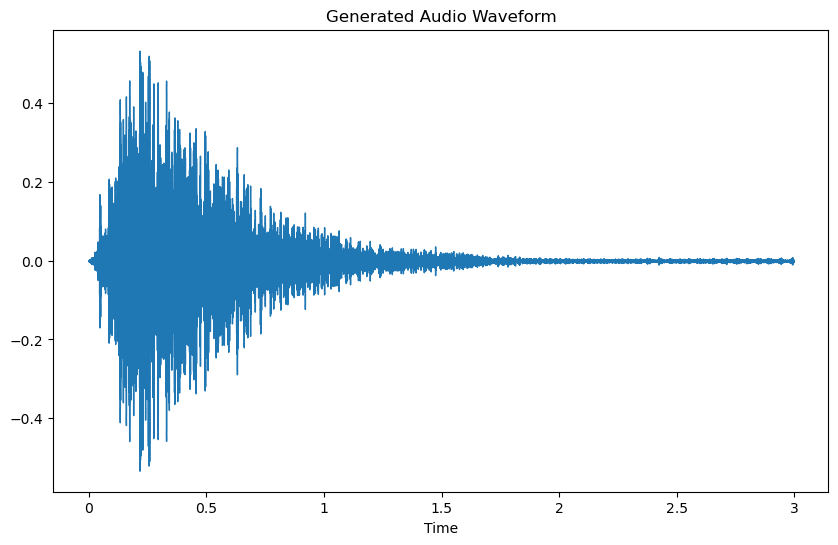

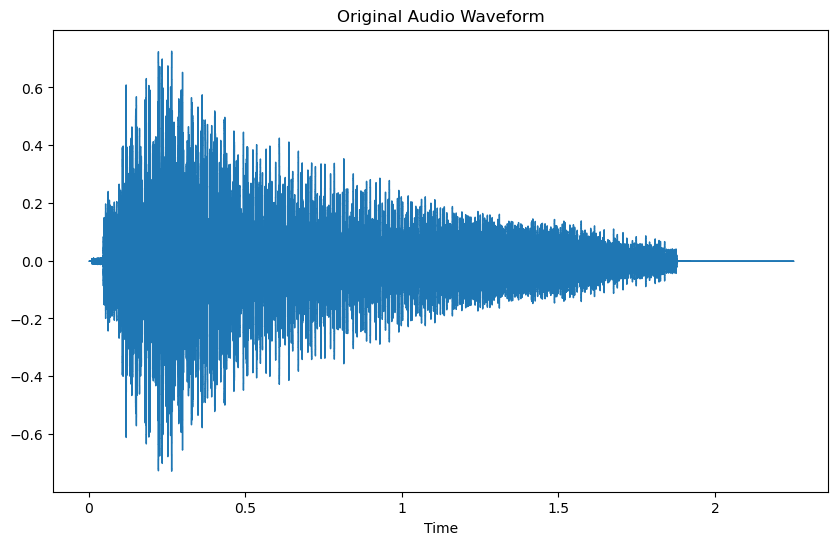

In [28]:
# Plot the spectrogram of the generated audio
plt.figure(figsize=(10, 6))
librosa.display.waveshow(generated_audio, sr=sr)
plt.title("Generated Audio Waveform")
plt.show()

plt.figure(figsize = (10,6))
librosa.display.waveshow(y = y, sr = sr)
plt.title("Original Audio Waveform")
plt.show()

In [29]:
# Play the generated audio
import IPython.display as ipd
ipd.Audio(generated_audio, rate=sr)